In [23]:
import numpy as np
import pandas as pd

In [24]:
df = pd.read_csv('Phishing_Email.csv')

In [25]:
df.sample(5)

,Unnamed: 0,Email Text,Email Type
11500,11501,q : ' this ' and ' that ' dear linguists : som...,Safe Email
13242,13243,use Perl Daily NewsletterIn this issue:\n *...,Safe Email
4399,4399,picks from analyst with high - level precision...,Phishing Email
17091,17092,"pleo 0004 2000 daren , when i look back in cpr...",Safe Email
6866,6867,start date : 12 / 20 / 01 ; hourahead hour : 1...,Safe Email


In [26]:
df.shape

(18650, 3)

In [ ]:
# 1. Data cleaning
# 2. EDA
# 3. Text Preprocessing
# 4. Model building
# 5. Evaluation
# 6. Improvement
# 7. Website
# 8. Deploy

## 1. Data Cleaning

In [27]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18650 entries, 0 to 18649
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Unnamed: 0  18650 non-null  int64 
 1   Email Text  18634 non-null  object
 2   Email Type  18650 non-null  object
dtypes: int64(1), object(2)
memory usage: 437.2+ KB


In [28]:
# drop last 3 cols
df.drop(columns=['Unnamed: 0'],inplace=True)

In [29]:
df.sample(5)

,Email Text,Email Type
10153,\nDigital Dispatch Weekly NewsletterAll CNET\n...,Safe Email
9631,"class speaker vincent , we met last year when ...",Safe Email
17341,"First, thanks for all the rpms, and especially...",Safe Email
17779,Justin Mason wrote:\n> Phil R Lawrence said:\n...,Safe Email
17793,average teenagers with webcam terhe ' s no ear...,Phishing Email


In [30]:
# renaming the cols
df.rename(columns={'Email Text':'text','Email Type':'target'},inplace=True)
df.sample(5)

,text,target
9181,diwfib absolutely new levitra . check it ! tus...,Phishing Email
17266,ets toy & food drive with the holidays quickly...,Safe Email
725,">>>>> ""R"" == Robert Harley writes: R> 'Scu...",Safe Email
9538,overworked and underpaid ? are you over worked...,Phishing Email
7705,lenders want to offer you a mortgage,Phishing Email


In [31]:
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()

In [32]:
df['target'] = encoder.fit_transform(df['target'])

In [33]:
df.head()

,text,target
0,"re : 6 . 1100 , disc : uniformitarianism , re ...",1
1,the other side of * galicismos * * galicismo *...,1
2,re : equistar deal tickets are you still avail...,1
3,\nHello I am your hot lil horny toy.\n I am...,0
4,software at incredibly low prices ( 86 % lower...,0


In [ ]:
#1 safe email 
#0 phishing email 

In [34]:
# missing values
df.isnull().sum()

text      16
target     0
dtype: int64

In [35]:
# check for duplicate values
df.duplicated().sum()

1111

In [36]:
# remove duplicates
df = df.drop_duplicates(keep='first')

In [37]:
df.duplicated().sum()

0

In [38]:
df.shape

(17539, 2)

## 2.EDA

In [39]:
df.head()

,text,target
0,"re : 6 . 1100 , disc : uniformitarianism , re ...",1
1,the other side of * galicismos * * galicismo *...,1
2,re : equistar deal tickets are you still avail...,1
3,\nHello I am your hot lil horny toy.\n I am...,0
4,software at incredibly low prices ( 86 % lower...,0


In [40]:
df['target'].value_counts()

target
1    10980
0     6559
Name: count, dtype: int64

In [19]:
%pip install matplotlib

Note: you may need to restart the kernel to use updated packages.


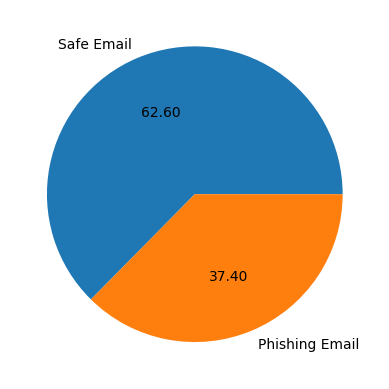

In [41]:
import matplotlib.pyplot as plt
plt.pie(df['target'].value_counts(), labels=['Safe Email','Phishing Email'],autopct="%0.2f")
plt.show()

In [ ]:
# Data is imbalanced

In [3]:
import nltk

In [ ]:
%pip install nltk

In [42]:
nltk.download('punkt')

[nltk_data] Downloading package punkt to C:\Users\Celine Ooi Zhi
[nltk_data]     Ni\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [43]:
df['text'] = df['text'].fillna('')

In [44]:
df['num_characters'] = df['text'].apply(len)

In [45]:
df.head()

,text,target,num_characters
0,"re : 6 . 1100 , disc : uniformitarianism , re ...",1,1030
1,the other side of * galicismos * * galicismo *...,1,479
2,re : equistar deal tickets are you still avail...,1,1245
3,\nHello I am your hot lil horny toy.\n I am...,0,688
4,software at incredibly low prices ( 86 % lower...,0,441


In [46]:
# num of words
df['num_words'] = df['text'].apply(lambda x:len(nltk.word_tokenize(x)))

In [47]:
df.head()

,text,target,num_characters,num_words
0,"re : 6 . 1100 , disc : uniformitarianism , re ...",1,1030,230
1,the other side of * galicismos * * galicismo *...,1,479,91
2,re : equistar deal tickets are you still avail...,1,1245,305
3,\nHello I am your hot lil horny toy.\n I am...,0,688,116
4,software at incredibly low prices ( 86 % lower...,0,441,91


In [48]:
df['num_sentences'] = df['text'].apply(lambda x:len(nltk.sent_tokenize(x)))

In [49]:
df.head()

,text,target,num_characters,num_words,num_sentences
0,"re : 6 . 1100 , disc : uniformitarianism , re ...",1,1030,230,10
1,the other side of * galicismos * * galicismo *...,1,479,91,7
2,re : equistar deal tickets are you still avail...,1,1245,305,8
3,\nHello I am your hot lil horny toy.\n I am...,0,688,116,8
4,software at incredibly low prices ( 86 % lower...,0,441,91,13


In [50]:
df=df[(df['num_words'] <= 10000) & (df['num_characters'] <= 10000000) & (df['num_sentences'] <= 100000)]

In [51]:
df[['num_characters','num_words','num_sentences']].describe().round()

,num_characters,num_words,num_sentences
count,17515.0,17515.0,17515.0
mean,1784.0,361.0,20.0
std,3031.0,587.0,47.0
min,0.0,0.0,0.0
25%,434.0,89.0,5.0
50%,914.0,188.0,10.0
75%,1936.0,393.0,19.0
max,129635.0,9666.0,3093.0


In [52]:
# Safe Email
df[df['target'] == 0][['num_characters','num_words','num_sentences']].describe().round()

,num_characters,num_words,num_sentences
count,6556.0,6556.0,6556.0
mean,1668.0,334.0,21.0
std,3181.0,580.0,54.0
min,0.0,0.0,0.0
25%,398.0,81.0,6.0
50%,763.0,157.0,10.0
75%,1669.0,329.0,20.0
max,129635.0,6602.0,3093.0


In [53]:
#Phishing Email
df[df['target'] == 1][['num_characters','num_words','num_sentences']].describe().round()

,num_characters,num_words,num_sentences
count,10959.0,10959.0,10959.0
mean,1854.0,377.0,19.0
std,2936.0,590.0,42.0
min,5.0,1.0,1.0
25%,468.0,96.0,5.0
50%,1019.0,210.0,9.0
75%,2048.0,420.0,19.0
max,47783.0,9666.0,1209.0


In [ ]:
%pip install seaborn

In [54]:
import seaborn as sns

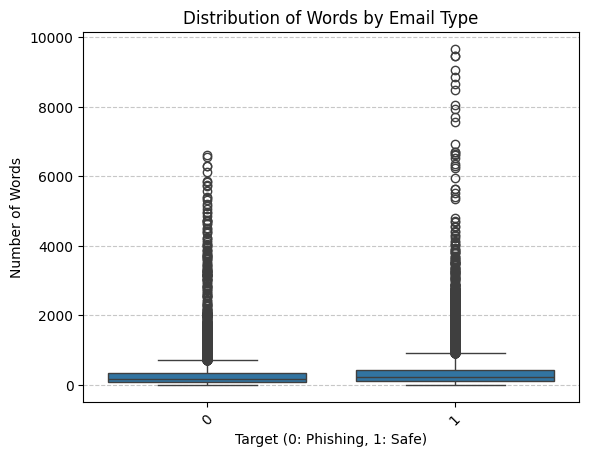

In [80]:
# Assuming your data has 'target' and 'num_words' columns
sns.boxplot(x='target', y='num_words', data=df)
plt.xlabel('Target (0: Phishing, 1: Safe)')
plt.ylabel('Number of Words')
plt.title('Distribution of Words by Email Type')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(rotation=45)
plt.show()

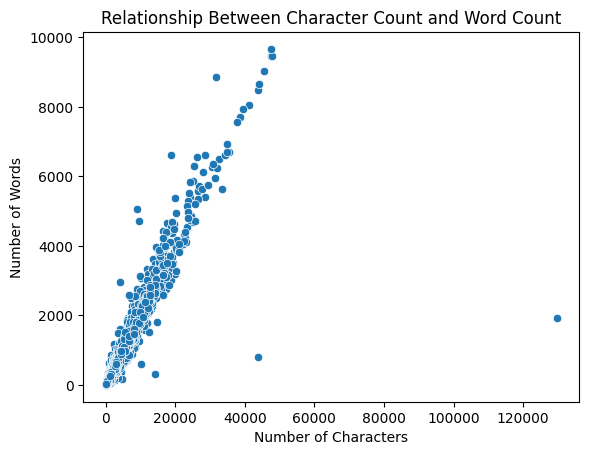

In [56]:
# Assuming your data has 'num_characters' and 'num_words' columns
sns.scatterplot(x='num_characters', y='num_words', data=df)
plt.xlabel('Number of Characters')
plt.ylabel('Number of Words')
plt.title('Relationship Between Character Count and Word Count')
plt.show()

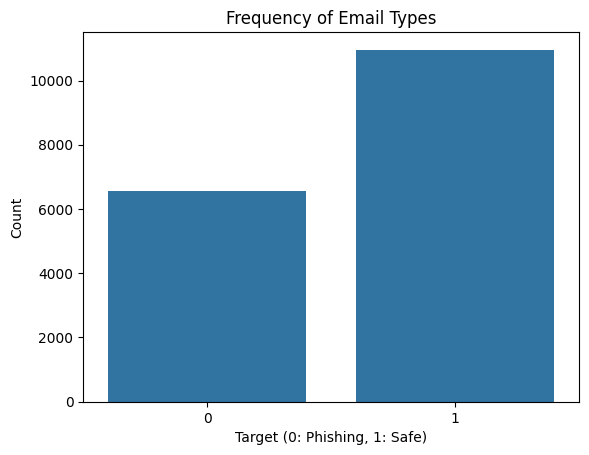

In [81]:
# Assuming your data has a 'target' column
sns.countplot(x='target', data=df)
plt.xlabel('Target (0: Phishing, 1: Safe)')
plt.ylabel('Count')
plt.title('Frequency of Email Types')
plt.show()


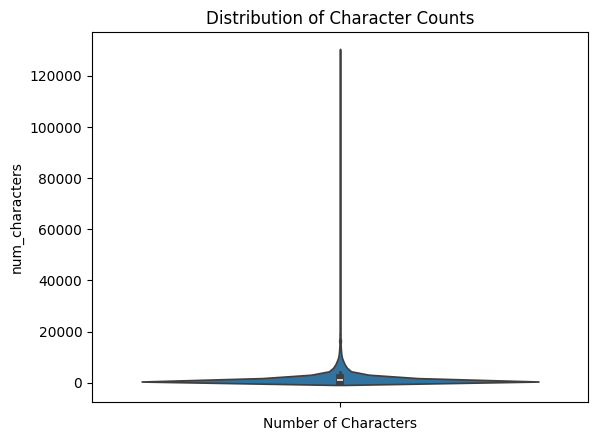

In [58]:
# Assuming your data has a 'num_characters' column
sns.violinplot(y='num_characters', data=df)
plt.xlabel('Number of Characters')
plt.title('Distribution of Character Counts')
plt.show()

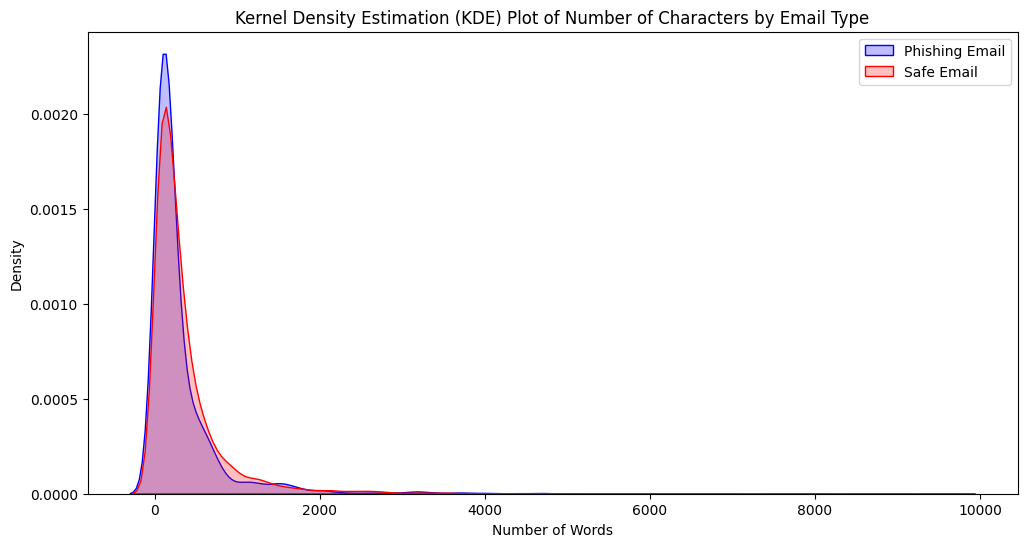

In [82]:
# plt.figure(figsize=(12,6))
# sns.histplot(df[df['target'] == 0]['num_words'])
# sns.histplot(df[df['target'] == 1]['num_words'],color='red')

plt.figure(figsize=(12, 6))

# Safe Email KDE plot
sns.kdeplot(df[df['target'] == 0]['num_words'], color='blue', label='Phishing Email', fill=True)

# Phishing Email KDE plot
sns.kdeplot(df[df['target'] == 1]['num_words'], color='red', label='Safe Email', fill=True)

# Add labels and title
plt.xlabel('Number of Words')
plt.ylabel('Density')
plt.title('Kernel Density Estimation (KDE) Plot of Number of Characters by Email Type')
plt.legend()

# Show plot
plt.show()

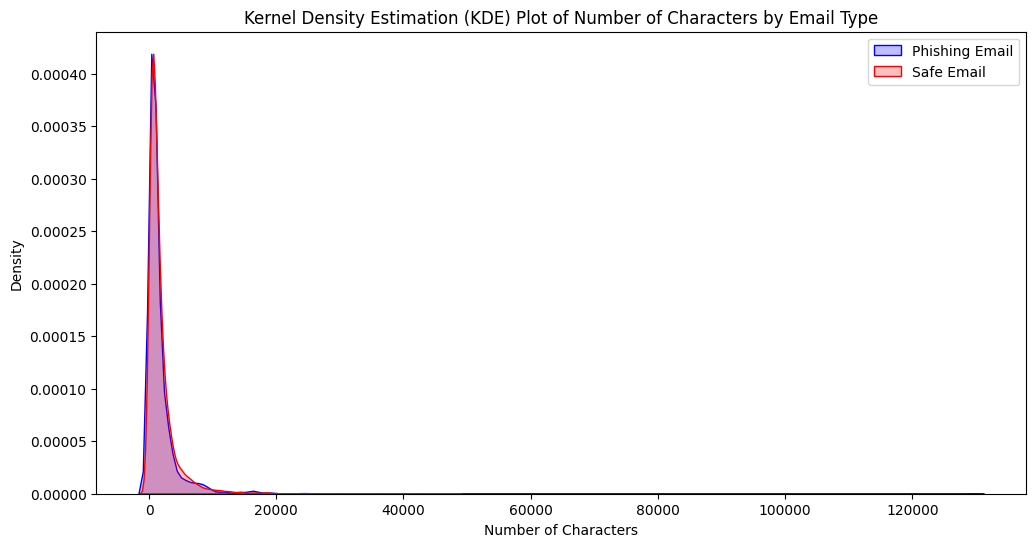

In [83]:
plt.figure(figsize=(12, 6))

# Safe Email KDE plot
sns.kdeplot(df[df['target'] == 0]['num_characters'], color='blue', label='Phishing Email', fill=True)

# Phishing Email KDE plot
sns.kdeplot(df[df['target'] == 1]['num_characters'], color='red', label='Safe Email', fill=True)

# Add labels and title
plt.xlabel('Number of Characters')
plt.ylabel('Density')
plt.title('Kernel Density Estimation (KDE) Plot of Number of Characters by Email Type')
plt.legend()

# Show plot
plt.show()

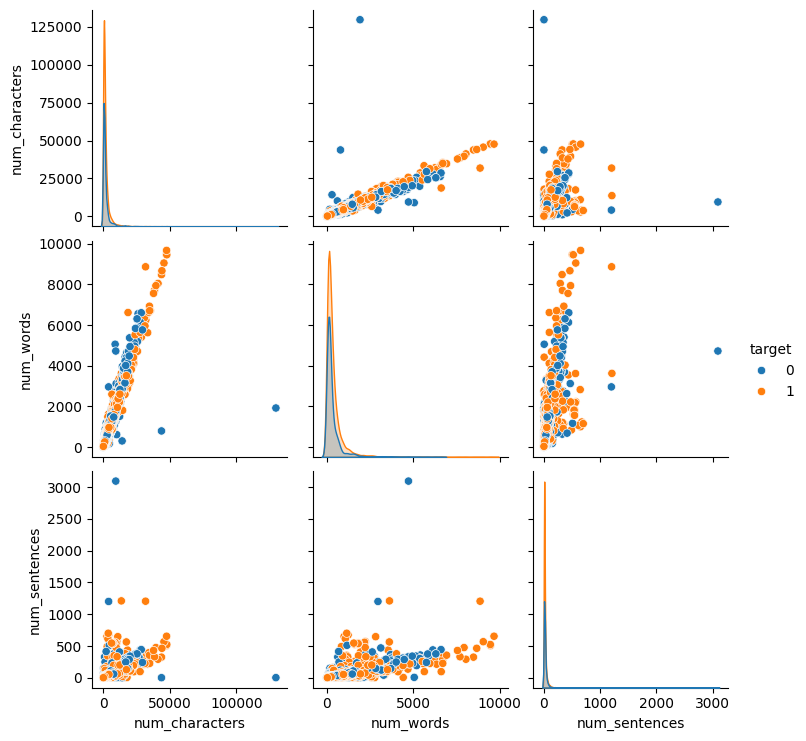

In [61]:
sns.pairplot(df,hue='target')

## 3. Data Preprocessing
- Lower case
- Tokenization
- Removing special characters
- Removing stop words and punctuation
- Stemming

In [62]:
from nltk.corpus import stopwords
import string
from nltk.stem import PorterStemmer

In [63]:
def transform_text(text):
    ps = PorterStemmer()
    text = text.lower()
    text = nltk.word_tokenize(text)
    
    y = []
    for i in text:
        if i.isalnum():
            y.append(i)
    
    text = y[:]
    y.clear()
    
    for i in text:
        if i not in stopwords.words('english') and i not in string.punctuation:
            y.append(i)
            
    text = y[:]
    y.clear()
    
    for i in text:
        y.append(ps.stem(i))
    
            
    return " ".join(y)

In [64]:
transform_text("I'm gonna be home soon and i don't want to talk about this stuff anymore tonight, k? I've cried enough today.")

'gon na home soon want talk stuff anymor tonight k cri enough today'

In [65]:
df['text'][10]

"make her beg you to give it to her everynight you too can please you and your partner so much better . and it doesn ' t take half a year like other solutions . if you don ' t trust me , trust the new york times , newsweek , time magazine , and the testemonials of many people all over the net . look , if anything else check out the site and see the facts for yourself its new , its safe ! its the most advanced penile enlargement solution ! it ' s 100 % guaranteed to enlarge your penis . 3 + inches magna - rx patch - click here the amazing , new magna rx patch is not available in any stores or on other websites . accept no imitations ! order your male enhancement patch now through this exclusive website offer and get a 1 - month supply free ! one small investment in yourself will last a lifetime ! - no pills or capsules - no lotions or cremes - no pumps , weights , or exercises - no prescription necessary - doctor designed endorsed - 100 % safe natural - more stamina energy - increase pe

In [66]:
from nltk.stem.porter import PorterStemmer
ps = PorterStemmer()
ps.stem('loving')

'love'

In [67]:
df['transformed_text'] = df['text'].apply(transform_text)

In [68]:
df.head()

,text,target,num_characters,num_words,num_sentences,transformed_text
0,"re : 6 . 1100 , disc : uniformitarianism , re ...",1,1030,230,10,6 1100 disc uniformitarian 1086 sex lang dick ...
1,the other side of * galicismos * * galicismo *...,1,479,91,7,side galicismo galicismo spanish term name imp...
2,re : equistar deal tickets are you still avail...,1,1245,305,8,equistar deal ticket still avail assist robert...
3,\nHello I am your hot lil horny toy.\n I am...,0,688,116,8,hello hot lil horni toy one dream open mind pe...
4,software at incredibly low prices ( 86 % lower...,0,441,91,13,softwar incred low price 86 lower draperi seve...


In [ ]:
%pip install wordcloud

In [71]:
from wordcloud import WordCloud
wc = WordCloud(width=500,height=500,min_font_size=10,background_color='white')

In [79]:
safe_wc = wc.generate(df[df['target'] == 1]['transformed_text'].str.cat(sep=" "))

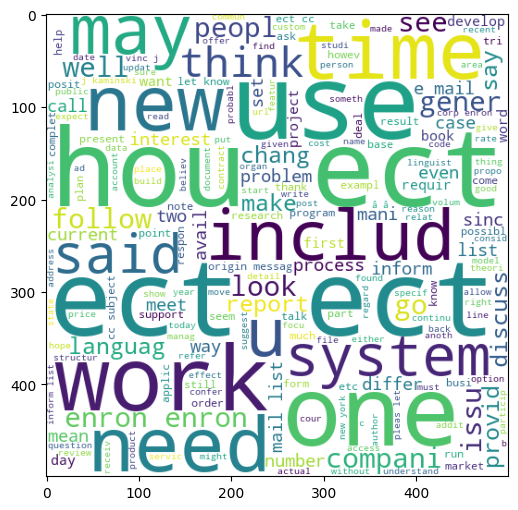

In [76]:
plt.figure(figsize=(15,6))
plt.imshow(safe_wc)

In [84]:
phish_wc = wc.generate(df[df['target'] == 0]['transformed_text'].str.cat(sep=" "))

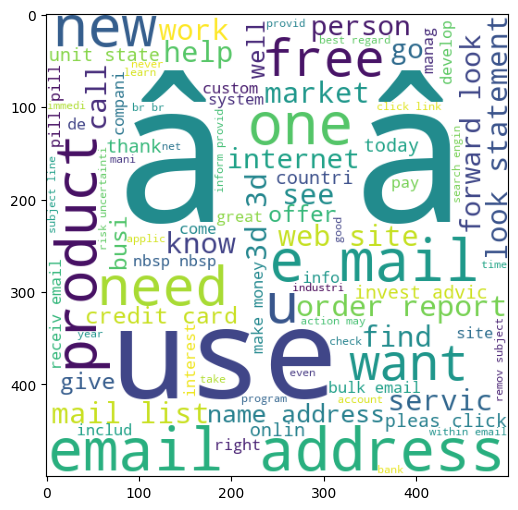

In [85]:
plt.figure(figsize=(15,6))
plt.imshow(phish_wc)

In [86]:
df.head()

,text,target,num_characters,num_words,num_sentences,transformed_text
0,"re : 6 . 1100 , disc : uniformitarianism , re ...",1,1030,230,10,6 1100 disc uniformitarian 1086 sex lang dick ...
1,the other side of * galicismos * * galicismo *...,1,479,91,7,side galicismo galicismo spanish term name imp...
2,re : equistar deal tickets are you still avail...,1,1245,305,8,equistar deal ticket still avail assist robert...
3,\nHello I am your hot lil horny toy.\n I am...,0,688,116,8,hello hot lil horni toy one dream open mind pe...
4,software at incredibly low prices ( 86 % lower...,0,441,91,13,softwar incred low price 86 lower draperi seve...


In [91]:
#create list of words
safe_corpus = []
for msg in df[df['target'] == 1]['transformed_text'].tolist():
    for word in msg.split():
        safe_corpus.append(word)
        

In [92]:
len(safe_corpus)

1873528

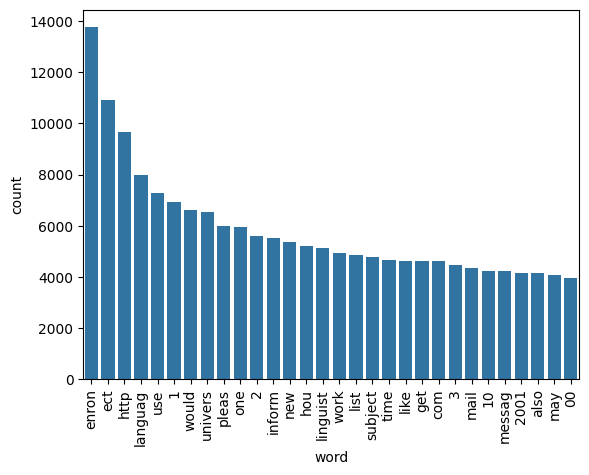

In [93]:
from collections import Counter
# Create a DataFrame from the Counter's most_common results
data = pd.DataFrame(Counter(safe_corpus).most_common(30), columns=['word', 'count'])

# Use seaborn's barplot function
sns.barplot(x='word', y='count', data=data)  # Pass the DataFrame directly

# Rotate x-axis labels for better readability
plt.xticks(rotation='vertical')

# Display the plot
plt.show()

In [94]:
phish_corpus = []
for msg in df[df['target'] == 0]['transformed_text'].tolist():
    for word in msg.split():
        phish_corpus.append(word)

In [95]:
len(phish_corpus)

1021854

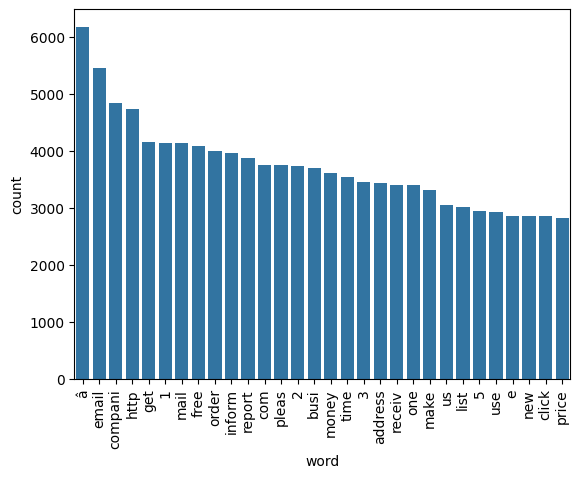

In [96]:
from collections import Counter
# Create a DataFrame from the Counter's most_common results
data = pd.DataFrame(Counter(phish_corpus).most_common(30), columns=['word', 'count'])

# Use seaborn's barplot function
sns.barplot(x='word', y='count', data=data)  # Pass the DataFrame directly

# Rotate x-axis labels for better readability
plt.xticks(rotation='vertical')

# Display the plot
plt.show()

In [97]:
# Text Vectorization
# using Bag of Words
df.head()

,text,target,num_characters,num_words,num_sentences,transformed_text
0,"re : 6 . 1100 , disc : uniformitarianism , re ...",1,1030,230,10,6 1100 disc uniformitarian 1086 sex lang dick ...
1,the other side of * galicismos * * galicismo *...,1,479,91,7,side galicismo galicismo spanish term name imp...
2,re : equistar deal tickets are you still avail...,1,1245,305,8,equistar deal ticket still avail assist robert...
3,\nHello I am your hot lil horny toy.\n I am...,0,688,116,8,hello hot lil horni toy one dream open mind pe...
4,software at incredibly low prices ( 86 % lower...,0,441,91,13,softwar incred low price 86 lower draperi seve...


## 4. Model Building

In [98]:
from sklearn.feature_extraction.text import CountVectorizer,TfidfVectorizer
cv = CountVectorizer()
tfidf = TfidfVectorizer(max_features=3000)

In [99]:
X = tfidf.fit_transform(df['transformed_text']).toarray()

In [ ]:
#from sklearn.preprocessing import MinMaxScaler
#scaler = MinMaxScaler()
#X = scaler.fit_transform(X)

In [ ]:
# appending the num_character col to X
#X = np.hstack((X,df['num_characters'].values.reshape(-1,1)))

In [100]:
X.shape

(17515, 3000)

In [101]:
y = df['target'].values

In [102]:
from sklearn.model_selection import train_test_split

In [103]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=2)

In [138]:
from sklearn.naive_bayes import GaussianNB,MultinomialNB,BernoulliNB
from sklearn.metrics import accuracy_score,confusion_matrix,precision_score,recall_score,f1_score

In [105]:
gnb = GaussianNB()
mnb = MultinomialNB()
bnb = BernoulliNB()

In [106]:
gnb.fit(X_train,y_train)
y_pred1 = gnb.predict(X_test)
print(accuracy_score(y_test,y_pred1))
print(confusion_matrix(y_test,y_pred1))
print(precision_score(y_test,y_pred1))

0.9397659149300599
[[1240   67]
 [ 144 2052]]
0.9683813119395942


In [107]:
mnb.fit(X_train,y_train)
y_pred2 = mnb.predict(X_test)
print(accuracy_score(y_test,y_pred2))
print(confusion_matrix(y_test,y_pred2))
print(precision_score(y_test,y_pred2))

0.9674564658863831
[[1251   56]
 [  58 2138]]
0.9744758432087511


In [108]:
bnb.fit(X_train,y_train)
y_pred3 = bnb.predict(X_test)
print(accuracy_score(y_test,y_pred3))
print(confusion_matrix(y_test,y_pred3))
print(precision_score(y_test,y_pred3))

0.924636026263203
[[1292   15]
 [ 249 1947]]
0.9923547400611621


In [ ]:
# tfidf --> MNB

In [ ]:
%pip install xgboost

In [111]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier

In [112]:
svc = SVC(kernel='sigmoid', gamma=1.0)
knc = KNeighborsClassifier()
mnb = MultinomialNB()
dtc = DecisionTreeClassifier(max_depth=5)
lrc = LogisticRegression(solver='liblinear', penalty='l1')
rfc = RandomForestClassifier(n_estimators=50, random_state=2)
abc = AdaBoostClassifier(n_estimators=50, random_state=2)
bc = BaggingClassifier(n_estimators=50, random_state=2)
etc = ExtraTreesClassifier(n_estimators=50, random_state=2)
gbdt = GradientBoostingClassifier(n_estimators=50,random_state=2)
xgb = XGBClassifier(n_estimators=50,random_state=2)

In [113]:
clfs = {
    'SVC' : svc,
    'KN' : knc, 
    'NB': mnb, 
    'DT': dtc, 
    'LR': lrc, 
    'RF': rfc, 
    'AdaBoost': abc, 
    'BgC': bc, 
    'ETC': etc,
    'GBDT':gbdt,
    'xgb':xgb
}

In [114]:
def train_classifier(clf,X_train,y_train,X_test,y_test):
    clf.fit(X_train,y_train)
    y_pred = clf.predict(X_test)
    accuracy = accuracy_score(y_test,y_pred)
    precision = precision_score(y_test,y_pred)
    
    return accuracy,precision

In [115]:
train_classifier(svc,X_train,y_train,X_test,y_test)

(0.974022266628604, 0.9830197338228546)

In [116]:
accuracy_scores = []
precision_scores = []

for name,clf in clfs.items():
    
    current_accuracy,current_precision = train_classifier(clf, X_train,y_train,X_test,y_test)
    
    print("For ",name)
    print("Accuracy - ",current_accuracy)
    print("Precision - ",current_precision)
    
    accuracy_scores.append(current_accuracy)
    precision_scores.append(current_precision)

For  SVC
Accuracy -  0.974022266628604
Precision -  0.9830197338228546
For  KN
Accuracy -  0.592634884384813
Precision -  0.9987029831387808
For  NB
Accuracy -  0.9674564658863831
Precision -  0.9744758432087511
For  DT
Accuracy -  0.8158721096203254
Precision -  0.8002322880371661
For  LR
Accuracy -  0.9691692834713103
Precision -  0.9806629834254144
For  RF
Accuracy -  0.9663145874964316
Precision -  0.9752973467520586


c:\Users\Celine Ooi Zhi Ni\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(


For  AdaBoost
Accuracy -  0.9152155295461033
Precision -  0.9580318379160637
For  BgC
Accuracy -  0.9489009420496717
Precision -  0.9628269848554383
For  ETC
Accuracy -  0.9745932058235798
Precision -  0.9760506100316313
For  GBDT
Accuracy -  0.9043676848415644
Precision -  0.8888424571667363
For  xgb
Accuracy -  0.9614616043391379
Precision -  0.9746660525103639


In [117]:
#Sort by precision 
performance_df = pd.DataFrame({'Algorithm':clfs.keys(),'Accuracy':accuracy_scores,'Precision':precision_scores}).sort_values('Precision',ascending=False)

In [118]:
performance_df

,Algorithm,Accuracy,Precision
1,KN,0.592635,0.998703
0,SVC,0.974022,0.983020
4,LR,0.969169,0.980663
8,ETC,0.974593,0.976051
5,RF,0.966315,0.975297
10,xgb,0.961462,0.974666
2,NB,0.967456,0.974476
7,BgC,0.948901,0.962827
6,AdaBoost,0.915216,0.958032
9,GBDT,0.904368,0.888842


In [119]:
#reshape df
performance_df1 = pd.melt(performance_df, id_vars = "Algorithm")

In [120]:
performance_df1

,Algorithm,variable,value
0,KN,Accuracy,0.592635
1,SVC,Accuracy,0.974022
2,LR,Accuracy,0.969169
3,ETC,Accuracy,0.974593
4,RF,Accuracy,0.966315
5,xgb,Accuracy,0.961462
6,NB,Accuracy,0.967456
7,BgC,Accuracy,0.948901
8,AdaBoost,Accuracy,0.915216
9,GBDT,Accuracy,0.904368


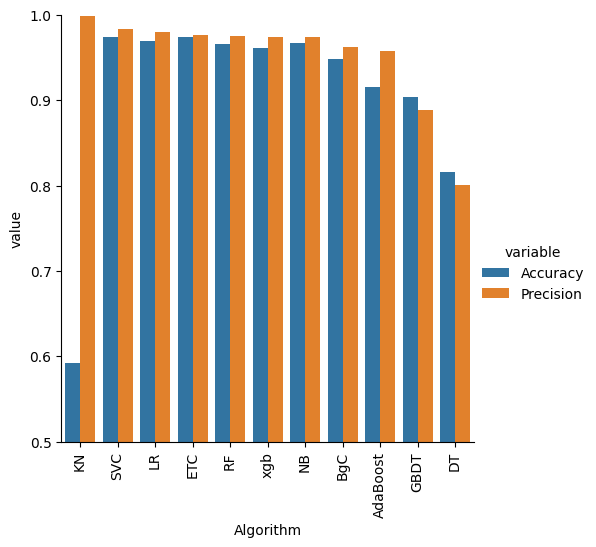

In [121]:
sns.catplot(x = 'Algorithm', y='value', 
               hue = 'variable',data=performance_df1, kind='bar',height=5)
plt.ylim(0.5,1.0)
plt.xticks(rotation='vertical')
plt.show()

In [ ]:
# model improve
# 1. Change the max_features parameter of TfIdf

In [122]:
# Sort precision score with hyperparameter 
temp_df = pd.DataFrame({'Algorithm':clfs.keys(),'Accuracy_max_ft_3000':accuracy_scores,'Precision_max_ft_3000':precision_scores}).sort_values('Precision_max_ft_3000',ascending=False)

In [123]:
# Sort precision score after scalling 
temp_df = pd.DataFrame({'Algorithm':clfs.keys(),'Accuracy_scaling':accuracy_scores,'Precision_scaling':precision_scores}).sort_values('Precision_scaling',ascending=False)

In [131]:
# merge temp_df and performance_df 
new_df = performance_df.merge(temp_df,on='Algorithm')

In [125]:
# merge 
new_df_scaled = new_df.merge(temp_df,on='Algorithm')

In [126]:
#summarize performance based on character count 
temp_df = pd.DataFrame({'Algorithm':clfs.keys(),'Accuracy_num_chars':accuracy_scores,'Precision_num_chars':precision_scores}).sort_values('Precision_num_chars',ascending=False)

In [127]:
# merge
new_df_scaled.merge(temp_df,on='Algorithm')

,Algorithm,Accuracy,Precision,Accuracy_scaling_x,Precision_scaling_x,Accuracy_scaling_y,Precision_scaling_y,Accuracy_num_chars,Precision_num_chars
0,KN,0.592635,0.998703,0.592635,0.998703,0.592635,0.998703,0.592635,0.998703
1,SVC,0.974022,0.983020,0.974022,0.983020,0.974022,0.983020,0.974022,0.983020
2,LR,0.969169,0.980663,0.969169,0.980663,0.969169,0.980663,0.969169,0.980663
3,ETC,0.974593,0.976051,0.974593,0.976051,0.974593,0.976051,0.974593,0.976051
4,RF,0.966315,0.975297,0.966315,0.975297,0.966315,0.975297,0.966315,0.975297
5,xgb,0.961462,0.974666,0.961462,0.974666,0.961462,0.974666,0.961462,0.974666
6,NB,0.967456,0.974476,0.967456,0.974476,0.967456,0.974476,0.967456,0.974476
7,BgC,0.948901,0.962827,0.948901,0.962827,0.948901,0.962827,0.948901,0.962827
8,AdaBoost,0.915216,0.958032,0.915216,0.958032,0.915216,0.958032,0.915216,0.958032
9,GBDT,0.904368,0.888842,0.904368,0.888842,0.904368,0.888842,0.904368,0.888842


In [128]:
# Voting Classifier
svc = SVC(kernel='sigmoid', gamma=1.0,probability=True)
mnb = MultinomialNB()
etc = ExtraTreesClassifier(n_estimators=50, random_state=2)

from sklearn.ensemble import VotingClassifier

In [129]:
voting = VotingClassifier(estimators=[('svm', svc), ('nb', mnb), ('et', etc)],voting='soft')

In [130]:
voting.fit(X_train,y_train)

VotingClassifier(estimators=[('svm',
                              SVC(gamma=1.0, kernel='sigmoid',
                                  probability=True)),
                             ('nb', MultinomialNB()),
                             ('et',
                              ExtraTreesClassifier(n_estimators=50,
                                                   random_state=2))],
                 voting='soft')

In [139]:
# predict unseen data
y_pred = voting.predict(X_test)
print("Accuracy",accuracy_score(y_test,y_pred))
print("Precision",precision_score(y_test,y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1-score:", f1_score(y_test, y_pred))


Accuracy 0.9780188409934342
Precision 0.984453589391861
Recall: 0.9804189435336976
F1-score: 0.9824321241159023


In [133]:
# Applying stacking
estimators=[('svm', svc), ('nb', mnb), ('et', etc)]
final_estimator=RandomForestClassifier()

In [134]:
from sklearn.ensemble import StackingClassifier

In [135]:
clf = StackingClassifier(estimators=estimators, final_estimator=final_estimator)

In [136]:
clf.fit(X_train,y_train)
y_pred = clf.predict(X_test)
print("Accuracy",accuracy_score(y_test,y_pred))
print("Precision",precision_score(y_test,y_pred))

Accuracy 0.9765914930059949
Precision 0.9866482504604052


In [140]:
import pickle
pickle.dump(tfidf,open('vectorizer.pkl','wb'))
pickle.dump(mnb,open('model.pkl','wb'))